In [1]:
import tensorflow as tf
import keras
from keras import layers
import os
import pickle
import numpy as np
import xarray
import matplotlib.pyplot as plt
import h5py
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
import random
import math
import pandas as pd
from scipy.special import ndtri
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
from keras.src.layers import concatenate
from keras.regularizers import L1,L2,L1L2


INPUT_SHAPE = (None, 72, 9, 9, 7)

tf.config.experimental.enable_op_determinism()
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

strategy = tf.distribute.MirroredStrategy()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
Dataset=xarray.open_dataset("/content/drive/MyDrive/everything.nc")
date=Dataset.time.values[5:-19]-np.timedelta64(5,'h')
# month = date.astype('datetime64[M]').astype(int) % 12 + (
#                (date.astype('datetime64[D]') - date.astype('datetime64[M]')).astype(int) + 1) / 31
# month=np.abs(np.cos((month-3)*2*np.pi/12))

# Convert the xarray dataset to a numpy array
data_array = Dataset.to_array()
data_array = data_array.to_numpy()
data_array = np.moveaxis(data_array, 0, -1)[5:-19,:,:,:]

print(data_array.shape)
Y=np.sum(np.lib.stride_tricks.sliding_window_view(data_array[48:,3,3,3],window_shape=24,axis=0)[::24],axis=1)
month = date.astype('datetime64[M]').astype(int) % 4
month=month[87::24]
X=np.copy(data_array[14:-10,:,:,:]).reshape(-1,24,9,9,7)
X=np.reshape(X,(-1,9,9,7))
M=np.lib.stride_tricks.sliding_window_view(X,window_shape=72,axis=0)[::24, :,:,:]
M=np.reshape(M,(-1,9,9,7,72))
M=np.rollaxis(M,-1,1)
print(M.shape)
Y[Y< 0] = 0
u=Y*1000
xb = np.concatenate((month.reshape(-1,1),u[:-1].reshape(-1,1)),axis=1)


(394440, 9, 9, 7)
(16432, 72, 9, 9, 7)


In [4]:
print(Dataset)

<xarray.Dataset> Size: 898MB
Dimensions:    (time: 394464, latitude: 9, longitude: 9)
Coordinates:
  * time       (time) datetime64[ns] 3MB 1978-01-01 ... 2022-12-31T23:00:00
  * latitude   (latitude) float32 36B -2.0 -2.25 -2.5 -2.75 ... -3.5 -3.75 -4.0
  * longitude  (longitude) float32 36B -80.0 -79.75 -79.5 ... -78.5 -78.25 -78.0
Data variables:
    t2m        (time, latitude, longitude) float32 128MB 302.4 300.5 ... 296.9
    cape       (time, latitude, longitude) float32 128MB 0.7922 35.54 ... 458.1
    p84.162    (time, latitude, longitude) float32 128MB 1.432e-05 ... -6.011...
    tp         (time, latitude, longitude) float32 128MB 1.863e-09 ... 6.128e-05
    q          (time, latitude, longitude) float32 128MB 0.004671 ... 0.006303
    tcwv       (time, latitude, longitude) float32 128MB 41.87 42.7 ... 42.06
    tcw        (time, latitude, longitude) float32 128MB 41.9 42.73 ... 42.24
Attributes:
    Conventions:  CF-1.6
    history:      2023-08-03 19:57:19 GMT by grib_to_ne

In [5]:
d=date[14:-10].reshape(-1,24)
d=np.reshape(d,(-1))
d=np.lib.stride_tricks.sliding_window_view(d,window_shape=72,axis=0)[::24]
d=np.reshape(d,(-1,72))
d=np.rollaxis(d,-1,1)
print(d[-3663,:])

['2012-12-17T14:00:00.000000000' '2012-12-17T15:00:00.000000000'
 '2012-12-17T16:00:00.000000000' '2012-12-17T17:00:00.000000000'
 '2012-12-17T18:00:00.000000000' '2012-12-17T19:00:00.000000000'
 '2012-12-17T20:00:00.000000000' '2012-12-17T21:00:00.000000000'
 '2012-12-17T22:00:00.000000000' '2012-12-17T23:00:00.000000000'
 '2012-12-18T00:00:00.000000000' '2012-12-18T01:00:00.000000000'
 '2012-12-18T02:00:00.000000000' '2012-12-18T03:00:00.000000000'
 '2012-12-18T04:00:00.000000000' '2012-12-18T05:00:00.000000000'
 '2012-12-18T06:00:00.000000000' '2012-12-18T07:00:00.000000000'
 '2012-12-18T08:00:00.000000000' '2012-12-18T09:00:00.000000000'
 '2012-12-18T10:00:00.000000000' '2012-12-18T11:00:00.000000000'
 '2012-12-18T12:00:00.000000000' '2012-12-18T13:00:00.000000000'
 '2012-12-18T14:00:00.000000000' '2012-12-18T15:00:00.000000000'
 '2012-12-18T16:00:00.000000000' '2012-12-18T17:00:00.000000000'
 '2012-12-18T18:00:00.000000000' '2012-12-18T19:00:00.000000000'
 '2012-12-18T20:00:00.000

In [6]:
df=pd.read_csv("/content/drive/MyDrive/df_rain_chirimachay.csv",usecols=["TIMESTAMP","Rain_mm_Tot"])

In [7]:
print(df.isnull().sum())

TIMESTAMP         0
Rain_mm_Tot    8066
dtype: int64


In [8]:
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])

# Extract the date part
df['date'] = df['TIMESTAMP'].dt.date

# Group and sum, but return NaN if all values are NaN
daily_rain = (
    df.groupby('date')['Rain_mm_Tot']
    .sum(min_count=10) #cuantos datos deben ser distintos de nan en el día para no retornar nan
    .reset_index()
)

print(daily_rain)

            date  Rain_mm_Tot
0     2012-10-02      0.00000
1     2012-10-03      0.00000
2     2012-10-04      0.61092
3     2012-10-05      6.31284
4     2012-10-06      0.00000
...          ...          ...
3807  2023-03-06      5.06016
3808  2023-03-07      4.11138
3809  2023-03-08      3.37344
3810  2023-03-09     13.28292
3811  2023-03-10      0.84336

[3812 rows x 2 columns]


In [9]:
daily_rain['year'] = pd.to_datetime(daily_rain['date']).dt.year
nans_per_year = daily_rain.groupby('year')['Rain_mm_Tot'].apply(lambda x: x.isnull().sum())
print("Number of NaNs in 'Rain_mm_Tot' per year:")
print(nans_per_year)

Number of NaNs in 'Rain_mm_Tot' per year:
year
2012     0
2013     2
2014     0
2015     0
2016     0
2017    11
2018     0
2019     0
2020     0
2021     0
2022     0
2023     0
Name: Rain_mm_Tot, dtype: int64


In [10]:
daily_rain['Rain_mm_Tot'] = daily_rain['Rain_mm_Tot'].fillna(0)

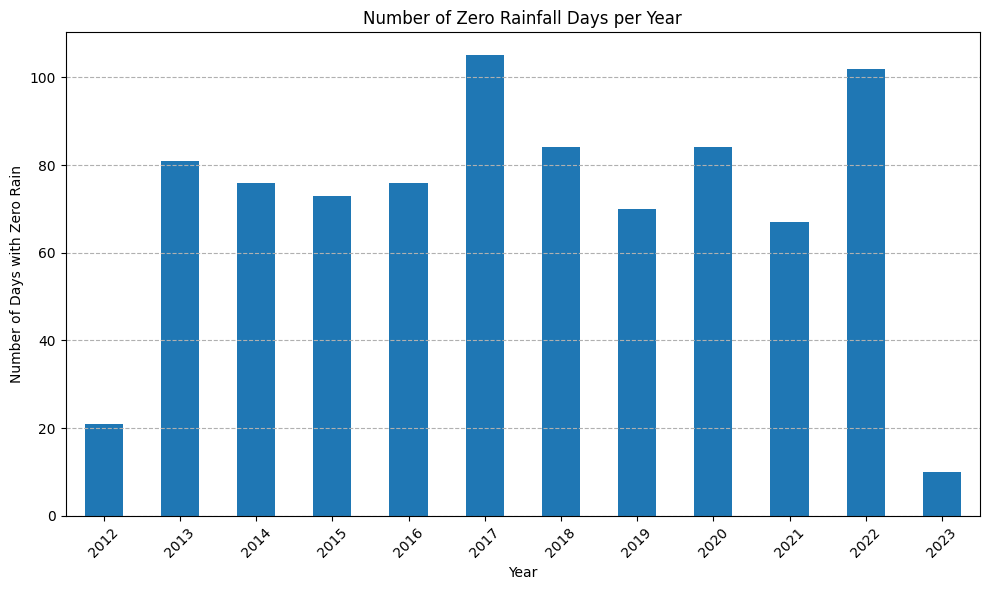

In [11]:
daily_rain['year'] = pd.to_datetime(daily_rain['date']).dt.year
zeros_per_year = daily_rain.groupby('year')['Rain_mm_Tot'].apply(lambda x: (x == 0).sum())

plt.figure(figsize=(10, 6))
zeros_per_year.plot(kind='bar')
plt.title('Number of Zero Rainfall Days per Year')
plt.xlabel('Year')
plt.ylabel('Number of Days with Zero Rain')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

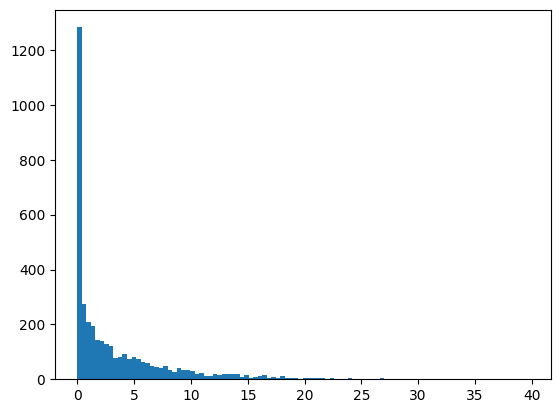

In [12]:
plt.hist(daily_rain['Rain_mm_Tot'],bins=100)
plt.show()

In [13]:

rain=daily_rain['Rain_mm_Tot'].to_numpy()

p33 = daily_rain['Rain_mm_Tot'].quantile(0.33)
p66 = daily_rain['Rain_mm_Tot'].quantile(0.66)
p90 = daily_rain['Rain_mm_Tot'].quantile(0.90)
p30 = daily_rain['Rain_mm_Tot'].quantile(0.30)
p63 = daily_rain['Rain_mm_Tot'].quantile(0.63)
p87 = daily_rain['Rain_mm_Tot'].quantile(0.87)
p36 = daily_rain['Rain_mm_Tot'].quantile(0.36)
p69 = daily_rain['Rain_mm_Tot'].quantile(0.69)
p92 = daily_rain['Rain_mm_Tot'].quantile(0.92)
sample_weight=np.ones_like(rain)
#sample_weight[(p30<rain) & (rain<p36)]=0.8
#sample_weight[(p63<rain) & (rain<p69)]=0.8
#sample_weight[(p87<rain) & (rain<p92)]=0.8

categorized_rain=np.zeros(len(daily_rain))
categorized_rain+=rain>p33
categorized_rain+=rain>p66
categorized_rain+=rain>p90
categorized_rain=categorized_rain.astype(int)

In [14]:
print(categorized_rain)

[0 0 1 ... 2 3 1]


In [15]:
print(p33)
print(p66)
print(p90)

0.3126
3.3410716000000056
9.688830000000001


In [16]:

if p33==0:
  mean1=0
else:
  mean1=np.mean(rain[rain<p33])
mean2=np.mean(rain[(rain>p33) & (rain<p66)])
mean3=np.mean(rain[(rain>p66) & (rain<p90)])
mean4=np.mean(rain[rain>p90])

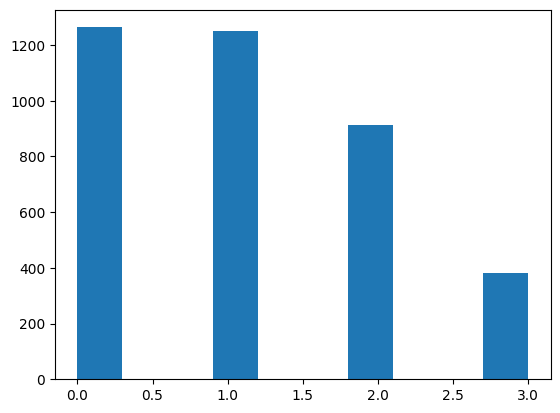

In [17]:
plt.hist(categorized_rain)
plt.show()

In [18]:
categorized_rain=tf.one_hot(categorized_rain,depth=4)
print(categorized_rain)

tf.Tensor(
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]], shape=(3812, 4), dtype=float32)


In [19]:
print(daily_rain["date"])

0       2012-10-02
1       2012-10-03
2       2012-10-04
3       2012-10-05
4       2012-10-06
           ...    
3807    2023-03-06
3808    2023-03-07
3809    2023-03-08
3810    2023-03-09
3811    2023-03-10
Name: date, Length: 3812, dtype: object


In [20]:
print(d[:,-1])

['1978-01-04T13:00:00.000000000' '1978-01-05T13:00:00.000000000'
 '1978-01-06T13:00:00.000000000' ... '2022-12-28T13:00:00.000000000'
 '2022-12-29T13:00:00.000000000' '2022-12-30T13:00:00.000000000']


In [21]:
print(d[:,-24])

['1978-01-03T14:00:00.000000000' '1978-01-04T14:00:00.000000000'
 '1978-01-05T14:00:00.000000000' ... '2022-12-27T14:00:00.000000000'
 '2022-12-28T14:00:00.000000000' '2022-12-29T14:00:00.000000000']


In [22]:

# Convert the last timestamp of each 72-hour window in 'd' to date objects
d_dates_for_matching = np.array([pd.to_datetime(window[-24]).date() for window in d])

# Extract dates from daily_rain DataFrame
daily_rain_dates = daily_rain['date'].values

# Find the intersection of dates common to both d_dates_for_matching and daily_rain
common_dates = np.intersect1d(d_dates_for_matching, daily_rain_dates)

# Create boolean masks for slicing based on common dates
indices_for_d = np.isin(d_dates_for_matching, common_dates)
indices_for_daily_rain = np.isin(daily_rain_dates, common_dates)

# Slice d, M, and xb
d_matched = d[indices_for_d]
M_matched = M[indices_for_d]
xb_matched = xb[indices_for_d]

# Slice daily_rain, categorized_rain, and rain
daily_rain_matched = daily_rain[indices_for_daily_rain].copy() # Use .copy() to avoid SettingWithCopyWarning
categorized_rain_matched = categorized_rain.numpy()[indices_for_daily_rain]
rain_matched = rain[indices_for_daily_rain]
sample_weight_matched=sample_weight[indices_for_daily_rain]
# Ensure all matched arrays are sorted by date
# daily_rain_matched is already sorted since daily_rain was sorted.
# Sort d_matched, M_matched, and xb_matched based on their corresponding dates
d_matched_dates_for_sorting = np.array([pd.to_datetime(window[-1]).date() for window in d_matched])
sort_order = np.argsort(d_matched_dates_for_sorting)

d_matched = d_matched[sort_order]
M_matched = M_matched[sort_order]
xb_matched = xb_matched[sort_order]
categorized_rain_matched = categorized_rain_matched[sort_order]
rain_matched = rain_matched[sort_order]
sample_weight_matched=sample_weight_matched[sort_order]

print(f"Shape of d_matched: {d_matched.shape}")
print(f"Shape of M_matched: {M_matched.shape}")
print(f"Shape of xb_matched: {xb_matched.shape}")
print(f"Shape of daily_rain_matched: {daily_rain_matched.shape}")
print(f"Shape of categorized_rain_matched: {categorized_rain_matched.shape}")
print(f"Shape of rain_matched: {rain_matched.shape}")

print(f"First date in d_matched (last element of window): {pd.to_datetime(d_matched[0,-1]).date()}")
print(f"Last date in d_matched (last element of window): {pd.to_datetime(d_matched[-1,-1]).date()}")
print(f"First date in daily_rain_matched: {daily_rain_matched['date'].iloc[0]}")
print(f"Last date in daily_rain_matched: {daily_rain_matched['date'].iloc[-1]}")

Shape of d_matched: (3741, 72)
Shape of M_matched: (3741, 72, 9, 9, 7)
Shape of xb_matched: (3741, 2)
Shape of daily_rain_matched: (3741, 3)
Shape of categorized_rain_matched: (3741, 4)
Shape of rain_matched: (3741,)
First date in d_matched (last element of window): 2012-10-03
Last date in d_matched (last element of window): 2022-12-30
First date in daily_rain_matched: 2012-10-02
Last date in daily_rain_matched: 2022-12-29


In [23]:
print(daily_rain_matched["date"].to_numpy()[-1])

2022-12-29


In [24]:
X_train_transfer=M_matched[-365*4:]
xb_train_transfer=xb_matched[-365*4:]
y_train_transfer=categorized_rain_matched[-365*4:]
sample_weight_train=sample_weight_matched[-365*4:]
X_test_transfer=M_matched[:-365*4]
xb_test_transfer=xb_matched[:-365*4]
y_test_transfer=categorized_rain_matched[:-365*4]

In [25]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.array([0,1,2,3]),y=np.argmax(y_train_transfer,axis=1))
print(class_weights)

[0.78833693 0.77991453 1.02816901 2.09770115]


In [26]:

with strategy.scope():
  model = keras.models.load_model('/content/drive/MyDrive/Modelos/saved_model1.keras')


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 11 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [27]:

with strategy.scope():
# Freeze all layers except dense4 and dense5
  for layer in model.layers[:]:
      layer.trainable = False
  #for layer in model.layers[-2:]:
  #    layer.trainable = True
  #model.layers[-4].trainable=True
  #model.layers[-6].trainable=True
 #add a relu layer at the end
  inputs = model.inputs  # Get the inputs of the original model
  z1=model.layers[-8].output
  z1=layers.Dense(8,activation='leaky_relu',kernel_regularizer=L1L2(l1=1e-5, l2=1e-6))(z1)
  z2=model.layers[-9].output
  z2=layers.Dense(8,activation='leaky_relu',kernel_regularizer=L1L2(l1=5e-3, l2=5e-4))(z2)
  z3=model.layers[-5].output
  z3=layers.Dense(8,activation='leaky_relu')(z3)
  z=concatenate([z1,z2,z3])
  z=layers.Dense(8,activation='tanh')(z)
  z=layers.Dense(4,use_bias=True,activation='softmax')(z)

  new_model = keras.Model(inputs=inputs, outputs=z)
# Print the trainable status of each layer to verify
for layer in new_model.layers:
  print(layer.name, layer.trainable)

input_layer_6 False
conv3d_12 False
conv3d_13 False
conv3d_14 False
conv3d_15 False
flatten_6 False
flatten_7 False
input_layer_7 False
dense True
dense_1 True
dense_2 True
concatenate True
dense_3 True
dense_4 True


In [28]:
new_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 72, 9, 9,  │          0 │ -                 │
│ (InputLayer)        │ 7)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_12 (Conv3D)  │ (None, 72, 9, 9,  │        504 │ input_layer_6[0]… │
│                     │ 42)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 72, 9, 9,  │          0 │ conv3d_12[0][0]   │
│                     │ 42)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_13 (Conv3D)  │ (None, 64, 7, 7,  │     54,432 │ re_lu_9[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigmoid_3 (Sigmoid) │ (None, 64, 7, 7,  │          0 │ conv3d_13[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_14 (Conv3D)  │ (None, 53, 4, 4,  │     61,440 │ sigmoid_3[0][0]   │
│                     │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 53, 4, 4,  │          0 │ conv3d_14[0][0]   │
│                     │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_15 (Conv3D)  │ (None, 30, 1, 1,  │    184,320 │ re_lu_10[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 30, 1, 1,  │          0 │ conv3d_15[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 720)       │          0 │ re_lu_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 16960)     │          0 │ re_lu_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │      5,768 │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │    135,688 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │         24 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │        200 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │         36 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 442,412 (1.69 MB)

 Trainable params: 141,716 (553.58 KB)

 Non-trainable params: 300,696 (1.15 MB)

In [29]:
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import F1Score

# Assuming X_train_transfer, y_train_transfer, xb_train_transfer are defined
# and new_model is your model


# Define the callback to save the best model based on validation loss
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_model_cat.keras',  # Path where the best model will be saved
    monitor='val_f1_score',  # Monitor validation loss (you can change this to 'val_mae' if you prefer MAE)
    mode='max',
    save_best_only=True,  # Save only the best model (according to validation loss)
    save_weights_only=False,  # Save the entire model, not just weights
    verbose=0  # Print information when the model is saved
)

# Convert class_weights from numpy array to dictionary
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

with strategy.scope():
    # Compile the model again after setting trainable layers
    new_model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalFocalCrossentropy(
    alpha=class_weights,
    gamma=1.,
    from_logits=False,
    label_smoothing=0.,
    axis=-1,
    reduction='sum_over_batch_size',
    name='categorical_focal_crossentropy'
)
    , metrics=['accuracy',F1Score(average='weighted', name='f1_score')])  # Choose appropriate optimizer, loss, and metrics

    # Train the model with the checkpoint callback
    history = new_model.fit(
        x=[X_train_transfer, xb_train_transfer],
        y=y_train_transfer,
        epochs=100,  # Adjust the number of epochs as needed
        batch_size=128, # Adjust the batch size
        validation_split=0.25,  # Use a validation split
        verbose=1,
        callbacks=[checkpoint]  # Add the checkpoint callback here
        ,sample_weight=sample_weight_train)



Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 412ms/step - accuracy: 0.2557 - f1_score: 0.1477 - loss: 5.4487 - val_accuracy: 0.3562 - val_f1_score: 0.2128 - val_loss: 3.1603
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - accuracy: 0.2941 - f1_score: 0.1686 - loss: 2.3813 - val_accuracy: 0.3507 - val_f1_score: 0.2602 - val_loss: 1.8296
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 429ms/step - accuracy: 0.3096 - f1_score: 0.2197 - loss: 1.8060 - val_accuracy: 0.3644 - val_f1_score: 0.2960 - val_loss: 1.5421
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.3187 - f1_score: 0.2465 - loss: 1.4348 - val_accuracy: 0.3836 - val_f1_score: 0.3429 - val_loss: 1.3281
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.3288 - f1_score: 0.2871 - loss: 1.2662 - val_accuracy: 0.3534 - val_f1_score: 0.3130 - val_loss: 1.1901
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.3242 - f1_score: 0.2838 - loss: 1.1575 - val_accuracy: 0.3616 - val_f1_score: 0.3246 - va

In [30]:
    # Evaluate the model on the test set
    loss, accuracy,f1 = new_model.evaluate([X_test_transfer, xb_test_transfer], y_test_transfer, verbose=0)

    # Optionally save the final model as well (if desired)
    new_model.save('/content/drive/MyDrive/final_retrained_model.keras')  # Save final model after training


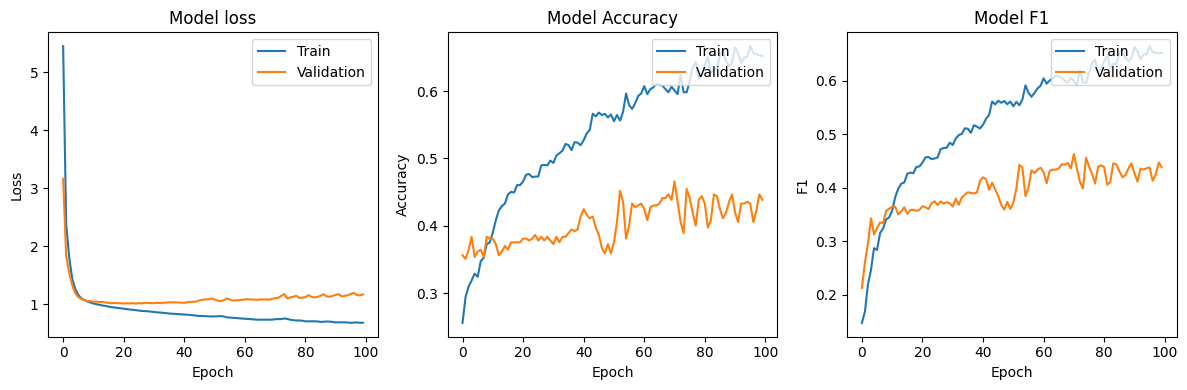

In [31]:
# Plot training & validation loss values
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

# Plot training & validation MAE values
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.subplot(1, 3, 3)
plt.plot(history.history['f1_score'])
plt.plot(history.history['val_f1_score'])
plt.title('Model F1')
plt.ylabel('F1')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')


plt.tight_layout()
plt.savefig('Loss_history_Balzay.pdf')
plt.show()

In [32]:
from keras.models import load_model

# Load the best model saved by the ModelCheckpoint callback
best_model = load_model('/content/drive/MyDrive/best_model_cat.keras')


In [33]:
pred_transfer=best_model.predict((X_test_transfer, xb_test_transfer))

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step


In [34]:
print(pred_transfer.shape)
print(y_test_transfer.shape)

(2281, 4)
(2281, 4)


Confusion Matrix:
[[467 238  55  22]
 [251 347  98  64]
 [107 213 125  94]
 [ 22  63  60  55]]


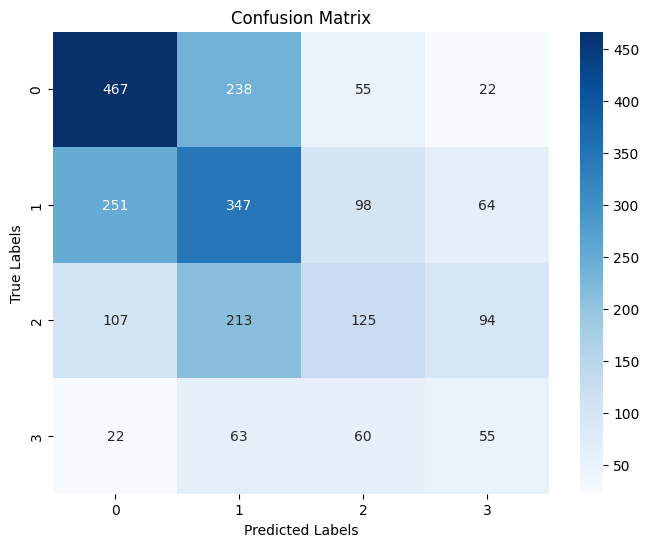

F1 Score (Weighted Average): 0.4287456288672771

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.60      0.57       782
           1       0.40      0.46      0.43       760
           2       0.37      0.23      0.29       539
           3       0.23      0.28      0.25       200

    accuracy                           0.44      2281
   macro avg       0.39      0.39      0.38      2281
weighted avg       0.43      0.44      0.43      2281



In [35]:
# prompt: create confusion matrix and print f1 score and detailed metrics

from sklearn.metrics import classification_report, f1_score

# Assuming pred_transfer and y_test_transfer are defined as in your code
# Convert probabilities to class labels
predicted_labels = np.argmax(pred_transfer, axis=1)
true_labels = np.argmax(y_test_transfer, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix (optional, but recommended)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
#plt.savefig('confusion_matrix_Balzay.pdf')
plt.show()

# Calculate and print the F1 score
f1 = f1_score(true_labels, predicted_labels, average='weighted')  # Use 'weighted' for multi-class
print(f"F1 Score (Weighted Average): {f1}")

# Calculate and print other metrics (precision, recall, F1-score per class)
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))


In [36]:

maxed_pred=np.eye(4)[np.argmax(pred_transfer,axis=1)]
df_predicted=pd.DataFrame(pred_transfer,columns=['0','1','2','3'])

df_predicted=pd.DataFrame(maxed_pred,columns=['0','1','2','3'])
df_true=pd.DataFrame(y_test_transfer,columns=['0','1','2','3'])
df_true["value"]=daily_rain_matched["Rain_mm_Tot"].iloc[:-365*4]
df_predicted["value"]=maxed_pred[:,0]*mean1+maxed_pred[:,1]*mean2+maxed_pred[:,2]*mean3+maxed_pred[:,3]*mean4
df_predicted["min_value"]=maxed_pred[:,0]*0+maxed_pred[:,1]*p33+maxed_pred[:,2]*p66+maxed_pred[:,3]*p90
df_predicted["max_value"]=maxed_pred[:,0]*p33+maxed_pred[:,1]*p66+maxed_pred[:,2]*p90+maxed_pred[:,3]*(p90+10)
df_predicted["date"]=daily_rain_matched["date"].iloc[:-365*4]
df_true["date"]=daily_rain_matched["date"].iloc[:-365*4]

In [37]:
df_predicted['date'] = pd.to_datetime(df_predicted['date'])
df_predicted.dropna(subset=['date'], inplace=True)
predicted_monthly = df_predicted.groupby(pd.Grouper(key='date', freq='ME')).sum()

df_true['date'] = pd.to_datetime(df_true['date'])
df_true.dropna(subset=['date'], inplace=True)
true_monthly = df_true.groupby(pd.Grouper(key='date', freq='ME')).sum()

In [38]:
predicted_monthly['month'] = predicted_monthly.index.month
predicted_monthly['year'] = predicted_monthly.index.year

true_monthly['month'] = true_monthly.index.month
true_monthly['year'] = true_monthly.index.year

print("predicted_monthly with new columns:")
print(predicted_monthly.head())
print("\ntrue_monthly with new columns:")
print(true_monthly.head())

predicted_monthly with new columns:
               0     1     2    3       value  min_value   max_value  month  \
date                                                                          
2012-10-31  12.0   9.0   6.0  3.0   95.353474  51.926320  151.020314     10   
2012-11-30   7.0  10.0  11.0  2.0  111.094679  59.255448  181.553706     11   
2012-12-31  14.0  10.0   5.0  2.0   76.040681  39.209018  125.608926     12   
2013-01-31  11.0  17.0   0.0  3.0   72.496666  34.380690  119.303307      1   
2013-02-28   3.0  14.0   5.0  6.0  142.135553  79.214738  214.289932      2   

            year  
date              
2012-10-31  2012  
2012-11-30  2012  
2012-12-31  2012  
2013-01-31  2013  
2013-02-28  2013  

true_monthly with new columns:
               0     1     2    3      value  month  year
date                                                     
2012-10-31   9.0  11.0   8.0  2.0  114.24204     10  2012
2012-11-30   6.0   7.0  13.0  4.0  153.23910     11  2012
2012-12-31  1

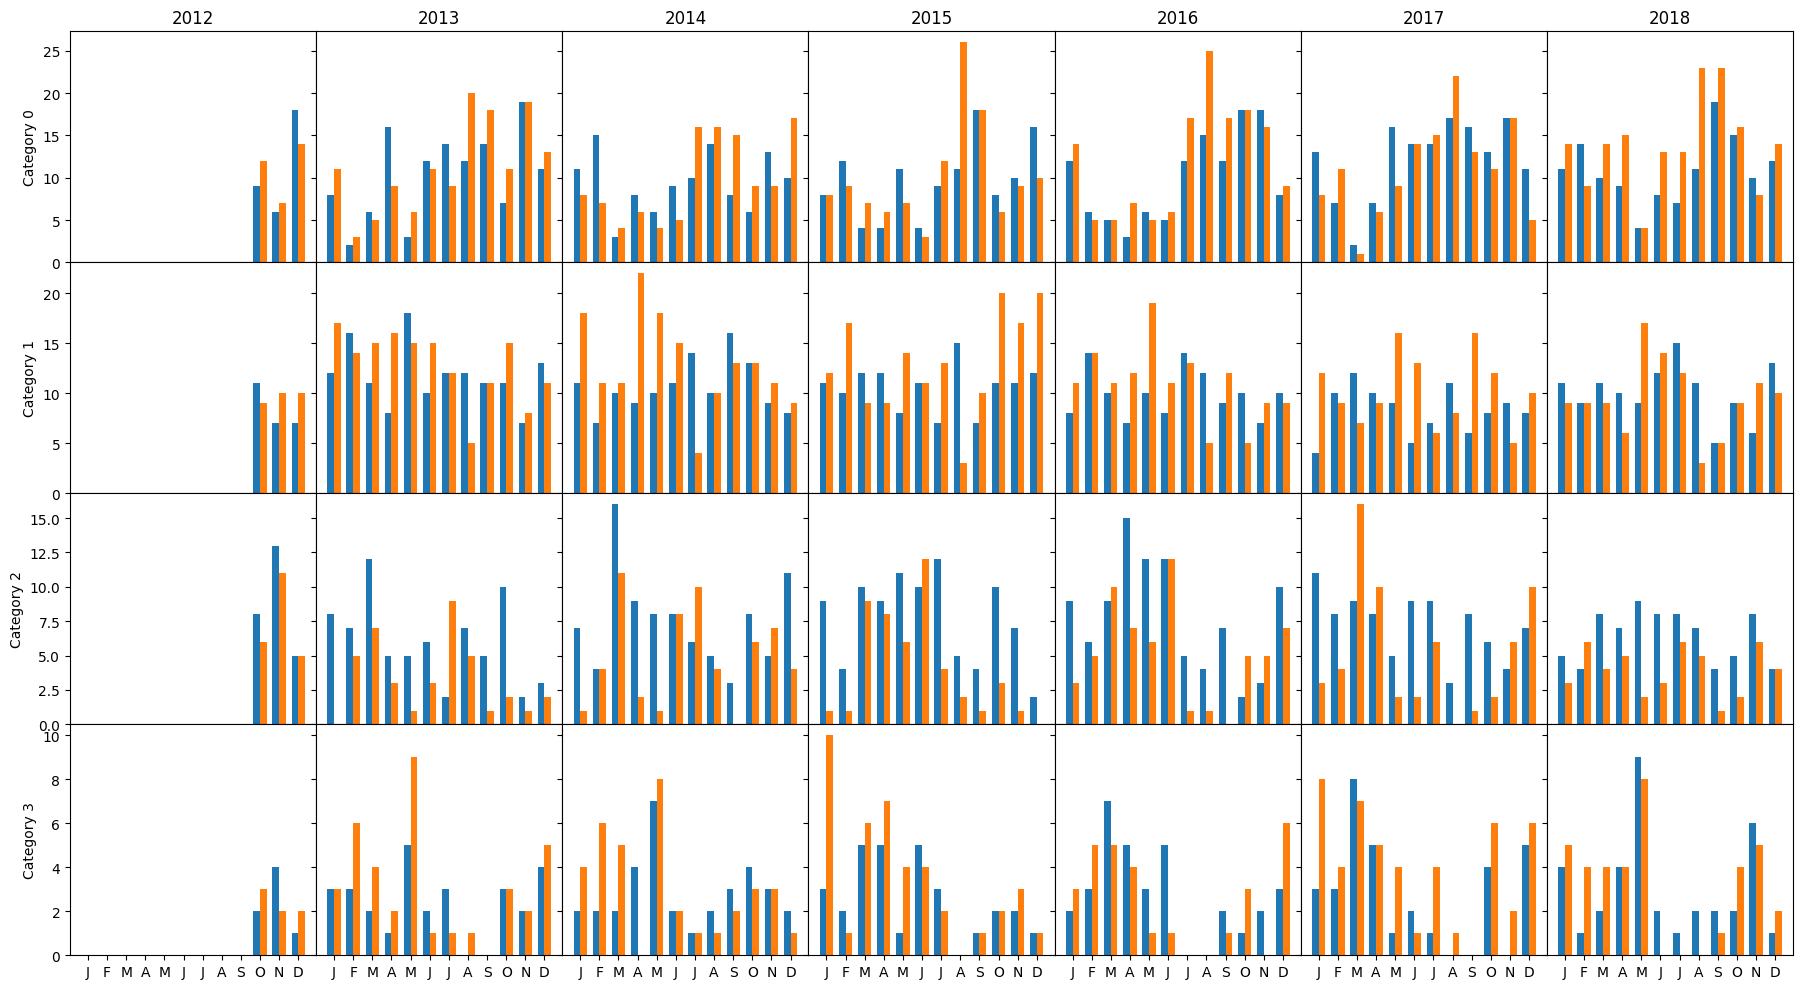

In [39]:


categories = [0, 1, 2, 3]
years = sorted(predicted_monthly["year"].unique())

fig, axes = plt.subplots(len(categories), len(years), figsize=(18, 10),sharex=True,sharey="row")

bar_width = 0.35

for i, cat in enumerate(categories):
    for j, year in enumerate(years):
        ax = axes[i, j]

        pred = predicted_monthly[predicted_monthly["year"] == year]
        true = true_monthly[true_monthly["year"] == year]

        # direct use of month column
        ax.bar(true["month"] - bar_width/2, true[str(cat)], width=bar_width)
        ax.bar(pred["month"] + bar_width/2, pred[str(cat)], width=bar_width)

        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

        if i == 0:
            ax.set_title(year)

        if j == 0:
            ax.set_ylabel(f"Category {cat}")

plt.tight_layout()

fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)
#plt.savefig('monthly_cats_balzay.pdf')
plt.show()

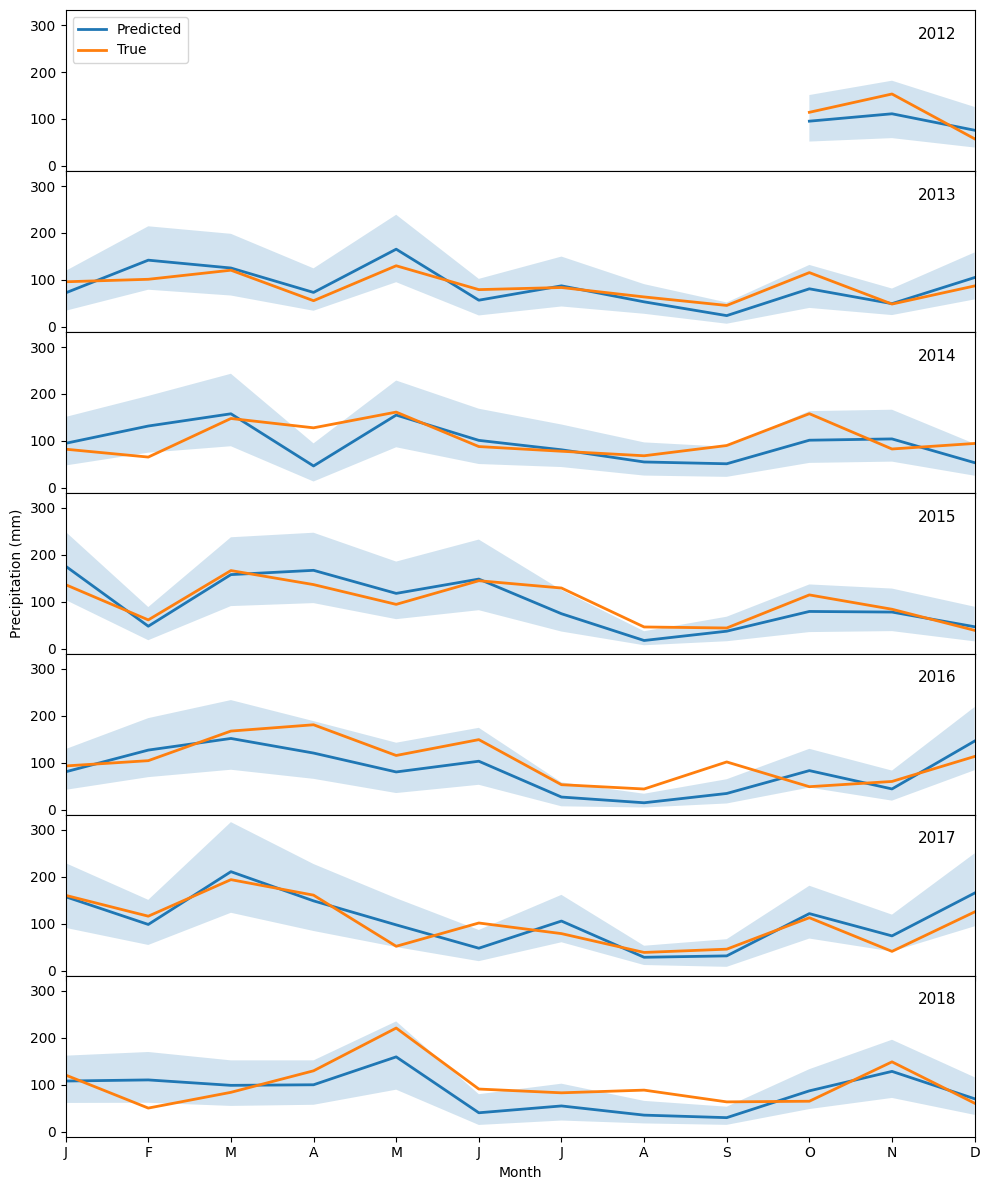

In [40]:


years = sorted(predicted_monthly["year"].unique())

fig, axes = plt.subplots(len(years), 1, figsize=(10, 12), sharex=True,sharey=True)

month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

for i, year in enumerate(years):
    ax = axes[i]

    pred = predicted_monthly[predicted_monthly["year"] == year]
    true = true_monthly[true_monthly["year"] == year]

    # align months (important if missing months exist)
    months = sorted(set(pred["month"]).union(set(true["month"])))
    x = np.array(months)

    pred = pred.set_index("month").reindex(months)
    true = true.set_index("month").reindex(months)

    # blue line: predicted mean
    ax.plot(x, pred["value"], label="Predicted", linewidth=2)

    # shaded area: min-max prediction interval
    ax.fill_between(x, pred["min_value"], pred["max_value"], alpha=0.2)

    # orange line: true values
    ax.plot(x, true["value"], label="True", linewidth=2)

    # styling
    ax.set_xlim(1, 12)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)

    ax.text(0.98, 0.85, str(year), transform=ax.transAxes,
            ha='right', va='center', fontsize=11)

    if i == len(years) // 2:
        ax.set_ylabel("Precipitation (mm)")

# optional: only one legend
axes[0].legend(loc="upper left")

plt.xlabel("Month")
plt.tight_layout()
fig.subplots_adjust(hspace=0)
#plt.savefig('monthly_rain_balzay.pdf')
plt.show()

In [41]:
def kge(sim, obs):
    sim = np.array(sim)
    obs = np.array(obs)

    # Remove NaNs if necessary
    mask = ~np.isnan(sim) & ~np.isnan(obs)
    sim = sim[mask]
    obs = obs[mask]

    r = np.corrcoef(sim, obs)[0, 1]  # Correlation coefficient
    alpha = np.std(sim) / np.std(obs)  # Variability ratio
    beta = np.mean(sim) / np.mean(obs)  # Bias ratio

    kge_value = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    return kge_value, r, alpha, beta


In [42]:

# The 'kge' function should be defined in a previous cell (p2Zh1t2UUXy7).
# The variables pred_cats, true_cats, avg_pred_monthly, and true_monthly
# are assumed to be available in the kernel state.

results = []
for i in range(4):
  kge_val, r_val, alpha_val, beta_val = kge(predicted_monthly[str(i)], true_monthly[str(i)])
  results.append({
      'Category': f'Category {i}',
      'KGE': kge_val,
      'r': r_val,
      'alpha': alpha_val,
      'beta': beta_val
  })

# Overall monthly KGE using average predicted monthly rainfall
kge_val_monthly, r_val_monthly, alpha_val_monthly, beta_val_monthly = kge(predicted_monthly["value"], true_monthly["value"])
results.append({
    'Category': 'Overall Monthly (Avg Pred)',
    'KGE': kge_val_monthly,
    'r': r_val_monthly,
    'alpha': alpha_val_monthly,
    'beta': beta_val_monthly
})

df_kge = pd.DataFrame(results)
display(df_kge.round(2))

,Category,KGE,r,alpha,beta
0,Category 0,0.56,0.66,1.25,1.08
1,Category 1,-0.11,0.04,1.54,1.13
2,Category 2,0.32,0.44,1.13,0.63
3,Category 3,0.51,0.63,1.27,1.17
4,Overall Monthly (Avg Pred),0.72,0.74,1.08,0.93
